# Análise: Preços de Alimentos × Obesidade nos EUA (2012–2018)

In [24]:
import sys
sys.path.insert(0, 'src')

import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

from dados        import carregar_dados
from exploracao   import explorar_cdc, explorar_usda
from limpeza      import limpar_cdc, filtrar_usda, agregar_usda_anual, criar_mapeamento_estados, criar_tabela_analitica
from visualizacoes import grafico_evolucao_precos_obesidade, grafico_correlacao_ratio_obesidade, grafico_obesidade_por_renda, grafico_evolucao_obesidade_renda, grafico_projecao_obesidade_renda
from estatisticas  import correlacoes_preco_obesidade, correlacao_renda_obesidade, tendencia_obesidade_por_renda
from features import preparar_features_renda
from modelos import comparar_modelos_regressao, extrair_coeficientes
con = duckdb.connect()

## Etapa 1-2 — Carregamento dos dados

In [25]:
df_cdc, df_usda = carregar_dados(con)

CDC já baixado, carregando do disco...
CDC  → 110,880 linhas x 33 colunas

USDA já baixado, carregando do disco...
USDA → 1,020,600 linhas x 6 colunas

Arquivos em data/: ['cdc_dados.csv', 'FMAP-Data.csv', 'FMAP-ReadMe.txt', 'graficos']

Tabelas disponíveis no DuckDB:
       name
0   cdc_raw
1  usda_raw


## Etapa 3 — Exploração do CDC

In [26]:
explorar_cdc(con)

1. Valores de Class:


,Class
0,Fruits and Vegetables
1,Obesity / Weight Status
2,Physical Activity


2. Valores de StratificationCategory1:


,StratificationCategory1,n
0,Race/Ethnicity,31680
1,Income,27720
2,Age (years),23760
3,Education,15840
4,Sex,7920
5,Total,3960


3. QuestionIDs dentro de 'Obesity / Weight Status':


...

,Stratification1,n
0,"$15,000 - $24,999",3960
1,"$25,000 - $34,999",3960
2,"$35,000 - $49,999",3960
3,"$50,000 - $74,999",3960
4,"$75,000 or greater",3960
5,Data not reported,3960
6,"Less than $15,000",3960


5. Anos disponíveis:


,YearStart
0,2011
1,2012
2,2013
3,2014
4,2015
5,2016
6,2017
7,2018
8,2019
9,2020


6. Localizações que serão excluídas:


,LocationAbbr
0,US
1,PR
2,GU
3,VI


## Etapa 4 — Limpeza e filtragem do CDC

In [27]:
cdc_geral, cdc_renda = limpar_cdc(con)

cdc_geral → 714 linhas x 4 colunas
cdc_renda → 2,142 linhas x 5 colunas


,Year,State,QuestionID,Obesity_Rate
0,2012,AK,Q036,25.7
1,2012,AK,Q037,39.1
2,2012,AL,Q036,33.0
3,2012,AL,Q037,34.8
4,2012,AR,Q036,34.5
5,2012,AR,Q037,34.2


,Year,State,QuestionID,Income_Group,Obesity_Rate
0,2012,AK,Q036,"$15,000 - $24,999",24.2
1,2012,AK,Q036,"$25,000 - $34,999",24.0
2,2012,AK,Q036,"$35,000 - $49,999",27.3
3,2012,AK,Q036,"$50,000 - $74,999",28.4
4,2012,AK,Q036,"$75,000 or greater",26.4
5,2012,AK,Q036,"Less than $15,000",29.4


## Etapa 5 — Exploração do USDA

In [28]:
explorar_usda(con)

1. Colunas e amostra:


,Year,Month,EFPG_code,Metroregion_code,Attribute,Value
0,2012,1,10000,0,Purchase_dollars_wtd,2.493734e+08
1,2012,1,10000,0,Purchase_grams_wtd,4.875195e+10
2,2012,1,10000,0,Purchase_dollars_unwtd,1.629852e+08



2. Atributos disponíveis:


,Attribute,n
0,Purchase_dollars_unwtd,113400
1,Purchase_grams_wtd,113400
2,Unit_value_mean_unwtd,113400
3,Unit_value_se_wtd,113400
4,Purchase_grams_unwtd,113400
5,Purchase_dollars_wtd,113400
6,Price_index_GEKS,113400
7,Number_stores,113400
8,Unit_value_mean_wtd,113400



3. Anos disponíveis:


...

,Metroregion_code,n
0,0,68040
1,1,68040
2,2,68040
3,3,68040
4,4,68040
5,12060,68040
6,14460,68040
7,16980,68040
8,19100,68040
9,19820,68040



5. Códigos de alimento (EFPG_code):


,codigo_min,codigo_max,total
0,10000,78000,90



Todos os EFPG_codes:


,EFPG_code
0,10000
1,10025
2,10050
3,10075
4,15000
5,15025
6,15050
7,15075
8,20000
9,20075


## Etapa 6 — Classificação e filtragem do USDA

In [29]:
usda_filtrado = filtrar_usda(con)

Linhas antes:  1,020,600
Linhas depois: 23,520

Distribuição por tipo:


,Food_Type,qtd_codigos,total_linhas
0,processed,22,7392
1,healthy,48,16128


,Year,Month,Metroregion_code,EFPG_code,Value,Food_Type
0,2012,1,1,10000,0.551337,healthy
1,2012,2,1,10000,0.552195,healthy
2,2012,3,1,10000,0.549603,healthy
3,2012,4,1,10000,0.548377,healthy
4,2012,5,1,10000,0.545741,healthy
5,2012,6,1,10000,0.544072,healthy
6,2012,7,1,10000,0.546840,healthy
7,2012,8,1,10000,0.542625,healthy


## Etapa 7 — Agregação anual do USDA

In [30]:
usda_anual = agregar_usda_anual(con)

Shape: (28, 5)


,Year,Metroregion_code,Price_Healthy,Price_Processed,Price_Ratio
0,2012,1,0.510638,0.539922,0.945763
1,2012,2,0.468235,0.495799,0.944405
2,2012,3,0.474816,0.504146,0.941823
3,2012,4,0.483893,0.533498,0.907020
4,2013,1,0.522589,0.545663,0.957715
5,2013,2,0.477446,0.501980,0.951127
6,2013,3,0.483863,0.509419,0.949833
7,2013,4,0.498220,0.542291,0.918732
8,2014,1,0.529767,0.551243,0.961042
9,2014,2,0.489560,0.513403,0.953559


## Etapa 8 — Mapeamento estado → região

In [31]:
df_mapeamento = criar_mapeamento_estados(con)

Total de estados mapeados: 51


,Metroregion_code,estados
0,1,9
1,2,12
2,3,17
3,4,13



Estados no CDC sem mapeamento (deve ser zero):


,State


## Etapa 9 — Tabela analítica final

In [32]:
df_analitico_precos, df_analitico_renda = criar_tabela_analitica(con)

analitico_precos → 714 linhas x 8 colunas
analitico_renda  → 2,142 linhas x 8 colunas

Nulos em analitico_precos: 0
Nulos em analitico_renda:  0

Tabelas no DuckDB:


,name
0,analitico_precos
1,analitico_renda
2,cdc_geral
3,cdc_raw
4,cdc_renda
5,state_region
6,usda_anual
7,usda_filtrado
8,usda_raw


,Year,State,QuestionID,Metroregion_code,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
0,2012,AK,Q036,4,25.7,0.483893,0.533498,0.907020
1,2012,AK,Q037,4,39.1,0.483893,0.533498,0.907020
2,2012,AL,Q036,3,33.0,0.474816,0.504146,0.941823
3,2012,AL,Q037,3,34.8,0.474816,0.504146,0.941823
4,2012,AR,Q036,3,34.5,0.474816,0.504146,0.941823
5,2012,AR,Q037,3,34.2,0.474816,0.504146,0.941823


,Year,State,Income_Group,Metroregion_code,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
0,2012,AK,"$15,000 - $24,999",4,24.2,0.483893,0.533498,0.90702
1,2012,AK,"$25,000 - $34,999",4,24.0,0.483893,0.533498,0.90702
2,2012,AK,"$35,000 - $49,999",4,27.3,0.483893,0.533498,0.90702
3,2012,AK,"$50,000 - $74,999",4,28.4,0.483893,0.533498,0.90702
4,2012,AK,"$75,000 or greater",4,26.4,0.483893,0.533498,0.90702
5,2012,AK,"Less than $15,000",4,29.4,0.483893,0.533498,0.90702


## Etapa 10 — Análise exploratória e visualizações

In [33]:
df_obesidade = con.execute("SELECT * FROM analitico_precos WHERE QuestionID = 'Q036'").df()
df_sobrepeso = con.execute("SELECT * FROM analitico_precos WHERE QuestionID = 'Q037'").df()

print(f'df_obesidade → {df_obesidade.shape[0]} linhas')
print(f'df_sobrepeso → {df_sobrepeso.shape[0]} linhas')

df_obesidade → 357 linhas
df_sobrepeso → 357 linhas


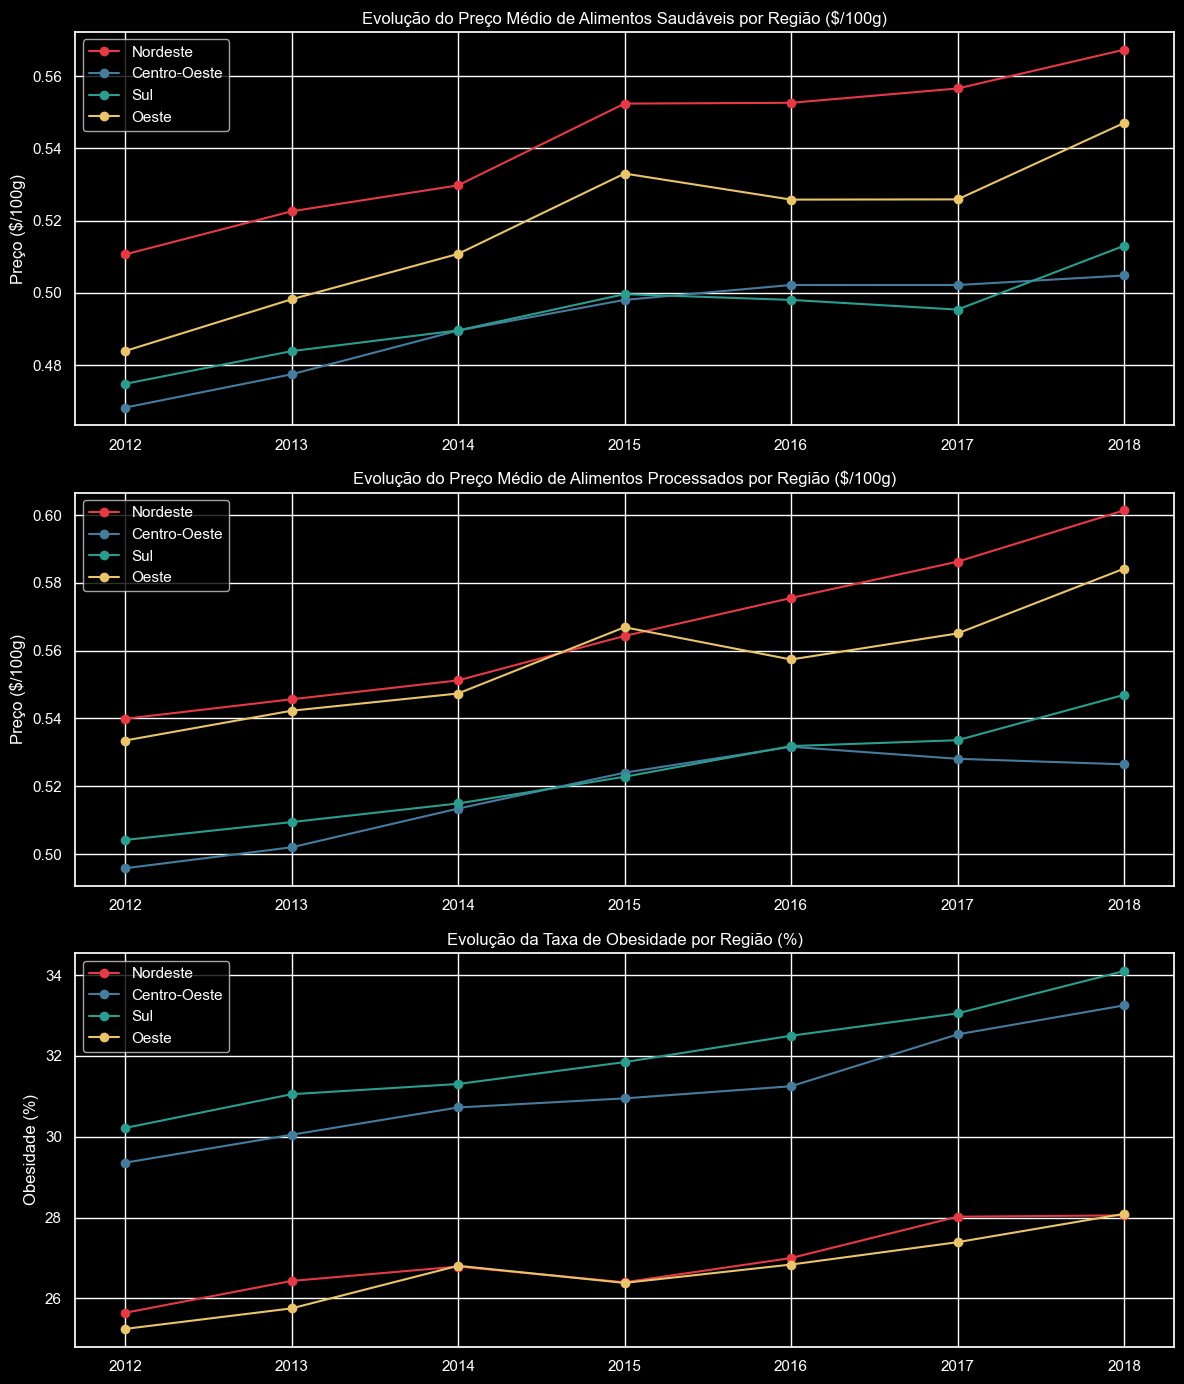

Salvo: data/graficos/fig1_evolucao_precos_obesidade.png


In [34]:
grafico_evolucao_precos_obesidade(df_obesidade)

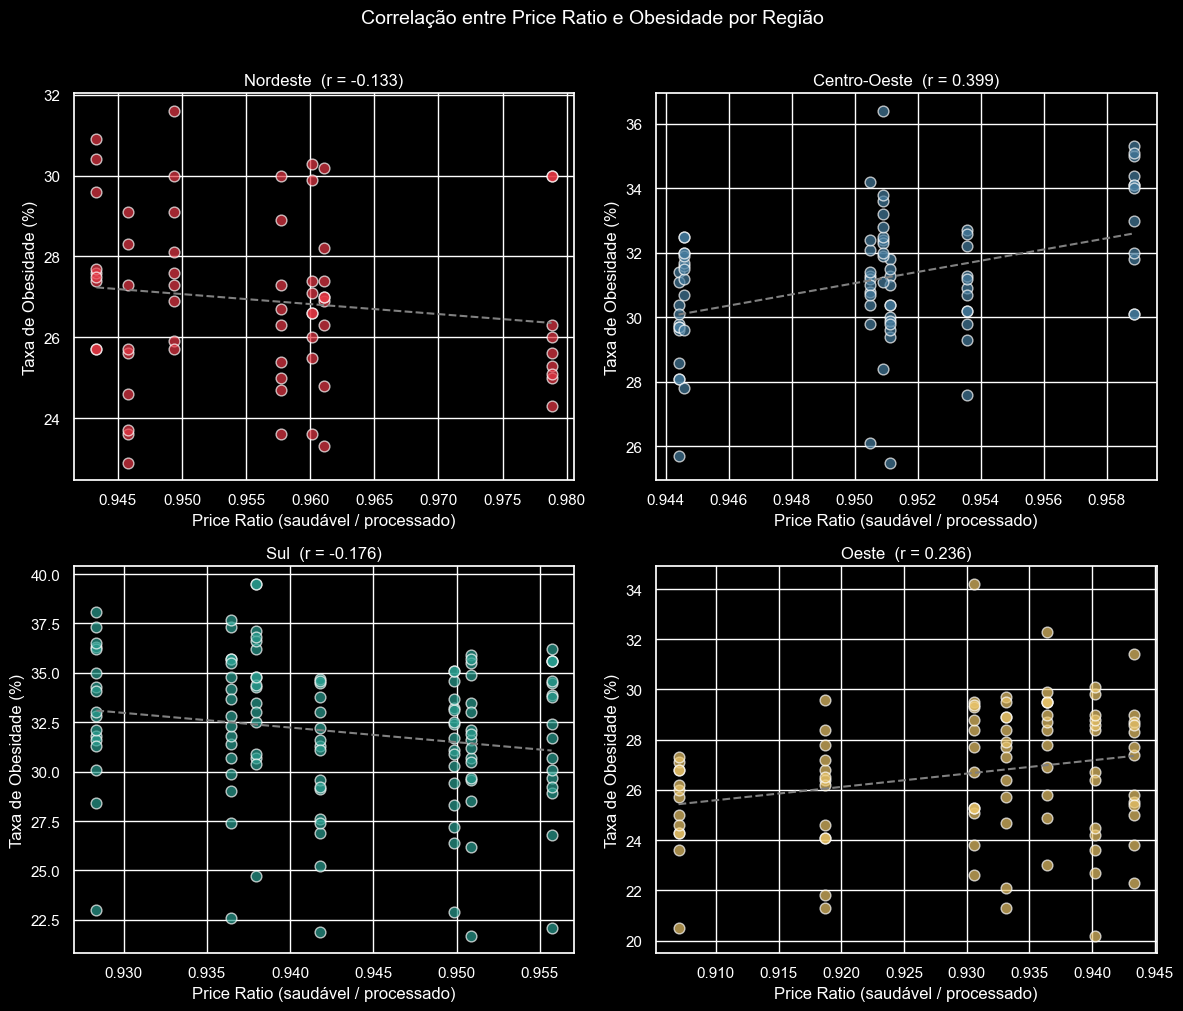

Salvo: data/graficos/fig2_correlacao_ratio_obesidade.png


In [35]:
grafico_correlacao_ratio_obesidade(df_obesidade)

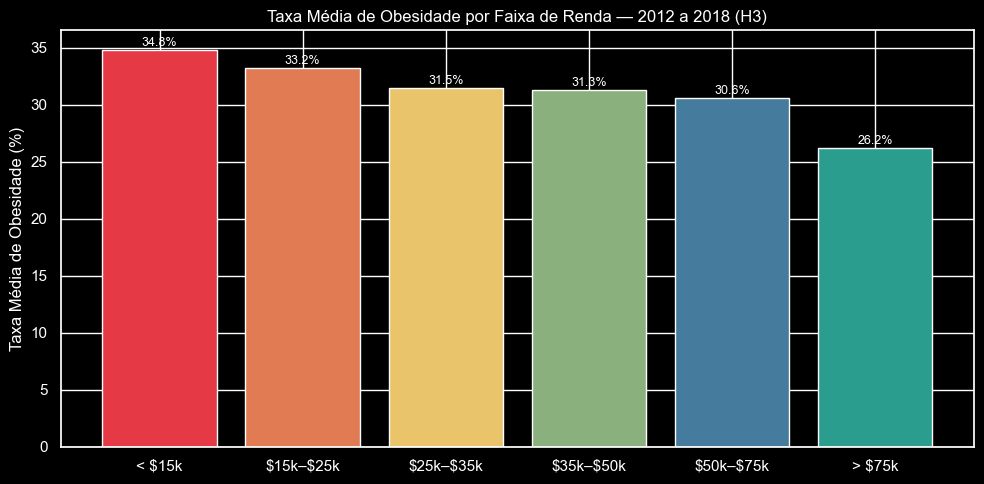

Salvo: data/graficos/fig3_obesidade_por_renda.png


In [36]:
grafico_obesidade_por_renda(df_analitico_renda)

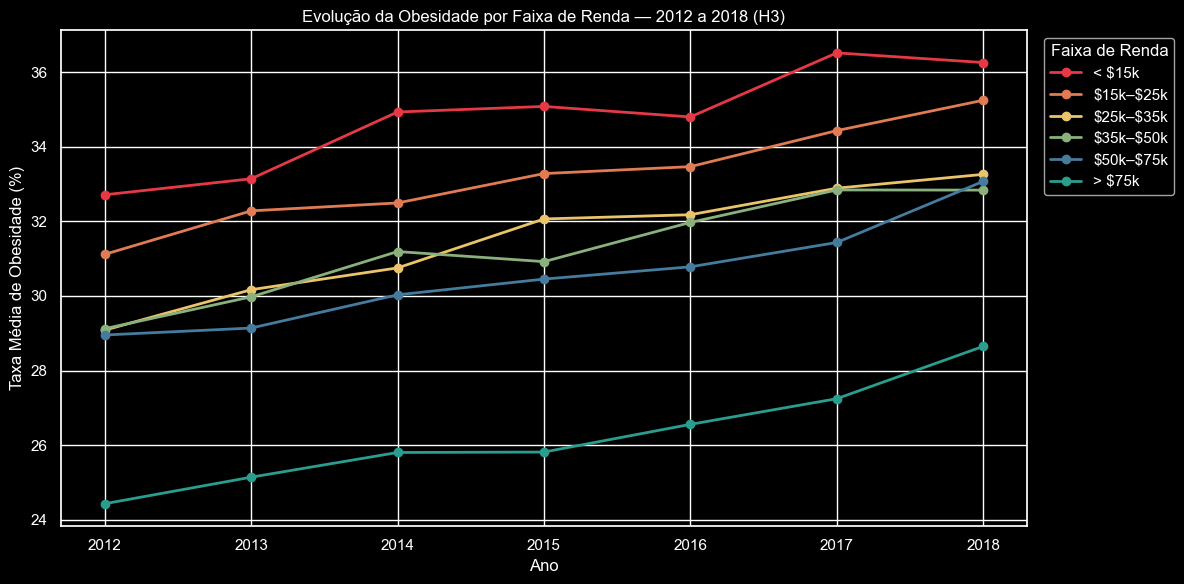

Salvo: data/graficos/fig4_evolucao_obesidade_renda.png


In [37]:
grafico_evolucao_obesidade_renda(df_analitico_renda)

## Etapa 10 — Correlações estatísticas

In [38]:
correlacoes_preco_obesidade(df_obesidade)

CORRELAÇÕES: Price_Ratio × Obesity_Rate por região
Nordeste        → r = -0.133  |  p = 0.2995  |  x não significativo
Centro-Oeste    → r = +0.399  |  p = 0.0002  |  v significativo
Sul             → r = -0.176  |  p = 0.0561  |  x não significativo
Oeste           → r = +0.236  |  p = 0.0242  |  v significativo

CORRELAÇÕES: Price_Healthy × Obesity_Rate por região
Nordeste        → r = +0.326  |  p = 0.0091  |  v significativo
Centro-Oeste    → r = +0.542  |  p = 0.0000  |  v significativo
Sul             → r = +0.300  |  p = 0.0009  |  v significativo
Oeste           → r = +0.294  |  p = 0.0046  |  v significativo



In [39]:
correlacao_renda_obesidade(df_analitico_renda)

CORRELAÇÃO GERAL: Renda × Obesidade (H3)
Renda (ordinal) × Obesidade → r = -0.488  |  p = 0.0000  |  v significativo


## Etapa 11 — H3: Renda × Obesidade

Testa se renda menor → obesidade maior (Passo 1: tendência por faixa de renda) e se a renda modera o efeito do preço de alimentos saudáveis (Passo 2: modelo combinado).

In [40]:
# Passo 1 — tendência e projeção por faixa de renda
media_por_grupo_ano, df_tendencias, df_previsoes = tendencia_obesidade_por_renda(df_analitico_renda)

Dados observados: 2012–2018 (7 anos)
Projetando 3 ano(s) além de 2018 (intervalo de predição a 95%)

Tendência por faixa de renda (Obesity_Rate ~ Year):


,Income_Group,slope,r,p_valor
0,"Less than $15,000",0.6168,0.9307,0.0023
1,"$15,000 - $24,999",0.6314,0.9858,0.0000
2,"$25,000 - $34,999",0.6932,0.9805,0.0001
3,"$35,000 - $49,999",0.6312,0.9700,0.0003
4,"$50,000 - $74,999",0.6324,0.9648,0.0004
5,"$75,000 or greater",0.6297,0.9706,0.0003



Projeção (com intervalo de predição):


,Income_Group,Year,Obesity_Rate_previsto,limite_inferior,limite_superior
0,"Less than $15,000",2019,37.25,35.32,39.18
1,"Less than $15,000",2020,37.87,35.76,39.97
2,"Less than $15,000",2021,38.48,36.19,40.78
3,"$15,000 - $24,999",2019,35.72,34.86,36.57
4,"$15,000 - $24,999",2020,36.35,35.42,37.28
5,"$15,000 - $24,999",2021,36.98,35.96,38.00
6,"$25,000 - $34,999",2019,34.26,33.15,35.37
7,"$25,000 - $34,999",2020,34.95,33.75,36.16
8,"$25,000 - $34,999",2021,35.65,34.33,36.96
9,"$35,000 - $49,999",2019,33.79,32.53,35.05


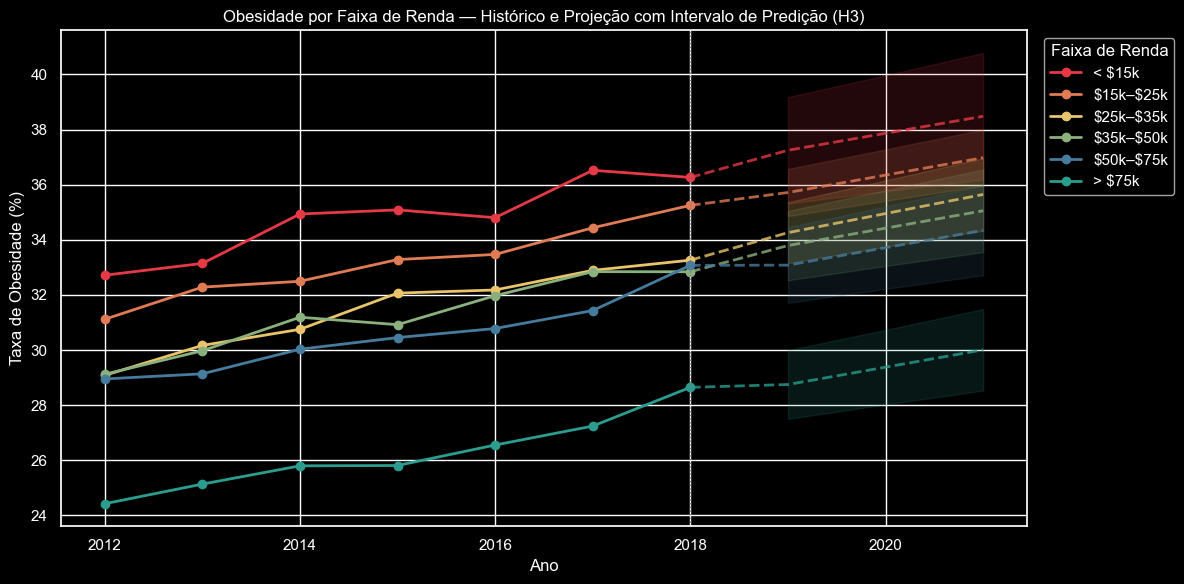

Salvo: data/graficos/fig5_projecao_obesidade_renda.png


In [41]:
grafico_projecao_obesidade_renda(media_por_grupo_ano, df_previsoes)

In [42]:
# Passo 2 — modelo combinado (renda, preços, região, ano)
X, y, groups = preparar_features_renda(df_analitico_renda)
df_resultados, info = comparar_modelos_regressao(X, y)
df_resultados

,Modelo,MAE,RMSE,R2
0,Baseline (média),4.025576,4.994854,-0.005013
1,Regressão Linear,2.699550,3.440419,0.523186
2,Random Forest,2.678583,3.442463,0.522619


In [43]:
extrair_coeficientes(info["modelos"]["Regressão Linear"], X.columns)

Income_Num             -2.532666
Regiao_Oeste           -1.846161
Year                    1.388321
Regiao_Nordeste        -1.034726
Regiao_Sul              0.582773
Price_Healthy          -0.488576
Price_Processed         0.125062
Renda_x_PriceHealthy   -0.104810
Price_Ratio             0.049636
dtype: float64

In [44]:
# checagem de multicolinearidade
X.corr().round(2)

,Income_Num,Price_Healthy,Price_Processed,Price_Ratio,Renda_x_PriceHealthy,Year,Regiao_Nordeste,Regiao_Oeste,Regiao_Sul
Income_Num,1.0,-0.00,-0.00,0.00,-0.0,-0.00,-0.00,-0.00,0.00
Price_Healthy,-0.0,1.00,0.96,0.22,-0.0,0.58,0.64,0.24,-0.41
Price_Processed,-0.0,0.96,1.00,-0.08,-0.0,0.58,0.51,0.43,-0.41
Price_Ratio,0.0,0.22,-0.08,1.00,-0.0,0.06,0.44,-0.61,-0.04
Renda_x_PriceHealthy,-0.0,-0.00,-0.00,-0.00,1.0,0.00,0.00,0.00,0.00
Year,-0.0,0.58,0.58,0.06,0.0,1.00,-0.00,0.00,-0.00
Regiao_Nordeste,-0.0,0.64,0.51,0.44,0.0,-0.00,1.00,-0.27,-0.33
Regiao_Oeste,-0.0,0.24,0.43,-0.61,0.0,0.00,-0.27,1.00,-0.41
Regiao_Sul,0.0,-0.41,-0.41,-0.04,0.0,-0.00,-0.33,-0.41,1.00


## Conclusão — H3

Vimos que a renda tem uma relação forte com a obesidade: quanto menor a renda, maior a taxa de obesidade, e essa diferença é grande e consistente.

Já não encontramos evidência de que a renda muda o efeito do preço da comida saudável sobre a obesidade — todas as faixas de renda cresceram em ritmo parecido ao longo dos anos, então a diferença entre ricos e pobres se manteve praticamente igual.

Também testamos um modelo mais complexo (Random Forest) e ele não foi melhor que um modelo simples, o que mostra que essa relação é bem direta, sem padrões escondidos.

Por fim, duas limitações: os preços de alimentos saudáveis e processados estão muito correlacionados entre si, então é difícil separar o efeito de cada um; e a projeção para os próximos anos tem bastante incerteza, principalmente entre as faixas de renda do meio.

## Etapa 12 - Regressão: preço dos alimentos e obesidade

Variável alvo:
Obesity_Rate

Preditores:
Price_Healthy
Price_Processed
Price_Ratio

In [45]:
# ── Etapa 10.1 — Preparar base para regressão ───────────────────────────────

df_reg = df_analitico_precos.copy()

# Usar apenas Q036 para não misturar indicadores diferentes de obesidade/peso
df_reg = df_reg[df_reg["QuestionID"] == "Q036"].copy()

# Selecionar apenas colunas necessárias
cols_modelo = [
    "Year",
    "State",
    "Metroregion_code",
    "Obesity_Rate",
    "Price_Healthy",
    "Price_Processed",
    "Price_Ratio"
]

df_reg = df_reg[cols_modelo].dropna()

print("Shape da base de regressão:", df_reg.shape)
display(df_reg.head())
display(df_reg.describe())

Shape da base de regressão: (357, 7)


,Year,State,Metroregion_code,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
0,2012,AK,4,25.7,0.483893,0.533498,0.907020
2,2012,AL,3,33.0,0.474816,0.504146,0.941823
4,2012,AR,3,34.5,0.474816,0.504146,0.941823
6,2012,AZ,4,26.0,0.483893,0.533498,0.907020
8,2012,CA,4,25.0,0.483893,0.533498,0.907020


,Year,Metroregion_code,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
count,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000
mean,2015.000000,2.666667,29.542017,0.507796,0.538035,0.943844
std,2.002807,1.043080,3.781129,0.024677,0.025502,0.013378
min,2012.000000,1.000000,20.200000,0.468235,0.495799,0.907020
25%,2013.000000,2.000000,26.800000,0.489606,0.522797,0.936449
50%,2015.000000,3.000000,29.700000,0.502172,0.533498,0.944405
75%,2017.000000,4.000000,32.100000,0.525828,0.551243,0.950899
max,2018.000000,4.000000,39.500000,0.567334,0.601417,0.978828


Matriz de correlação entre obesidade e variáveis de preço:


,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
Obesity_Rate,1.000,-0.291,-0.335,0.129
Price_Healthy,-0.291,1.000,0.956,0.221
Price_Processed,-0.335,0.956,1.000,-0.075
Price_Ratio,0.129,0.221,-0.075,1.000


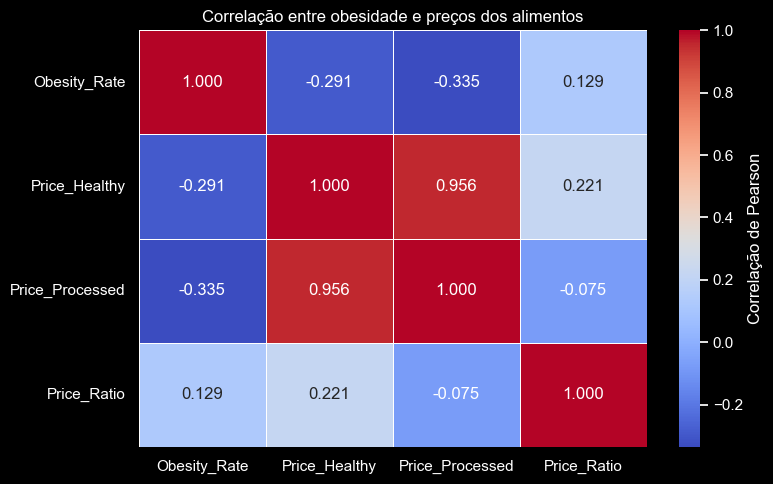

In [46]:
# ── Etapa 10.2 — Correlação entre preços e obesidade ─────────────────────────

# Nesta etapa, usamos somente o indicador Q036, preparado na etapa anterior.
# A análise abaixo verifica a associação inicial entre obesidade e preços,
# antes de aplicar os modelos de regressão.
import pandas as pd

corr_cols = [
    "Obesity_Rate",
    "Price_Healthy",
    "Price_Processed",
    "Price_Ratio"
]

# Garantir que as variáveis utilizadas na análise estejam em formato numérico.
df_reg[corr_cols] = df_reg[corr_cols].apply(pd.to_numeric, errors="coerce")
df_reg = df_reg.dropna(subset=corr_cols).copy()

correlacao = df_reg[corr_cols].corr().round(3)

print("Matriz de correlação entre obesidade e variáveis de preço:")
display(correlacao)

plt.figure(figsize=(8, 5))
sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Correlação de Pearson"}
)
plt.title("Correlação entre obesidade e preços dos alimentos")
plt.tight_layout()
plt.show()


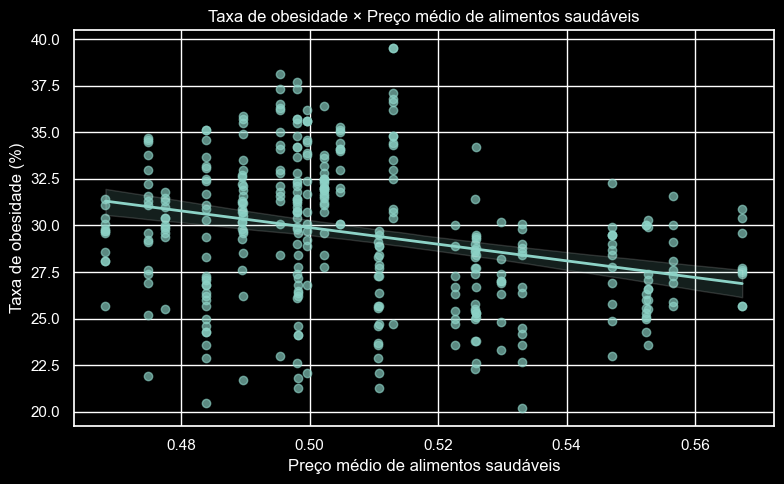

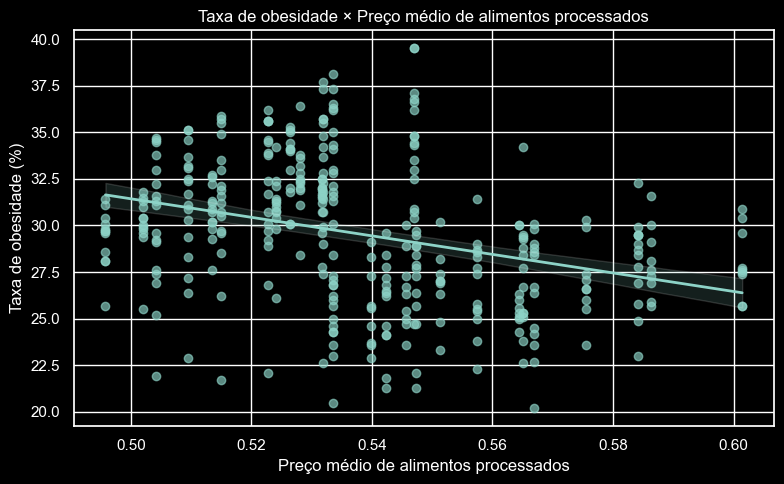

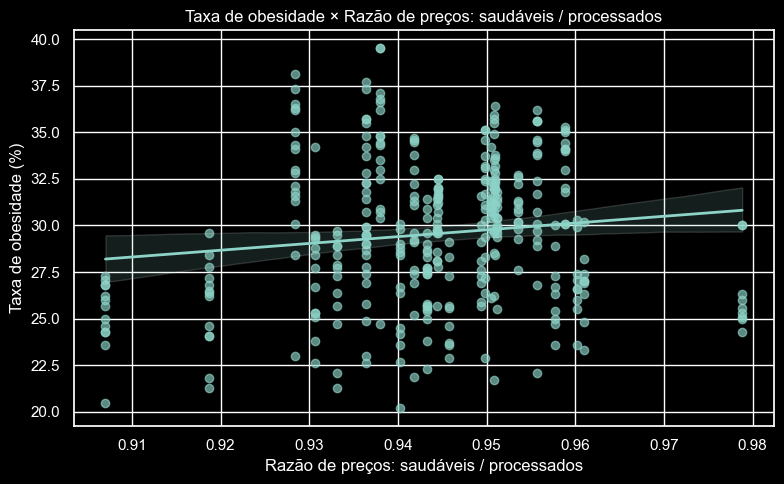

In [47]:
# ── Etapa 10.3 — Visualização da relação entre preços e obesidade ────────────

# Os gráficos de dispersão ajudam a observar visualmente se há tendência
# de aumento ou redução da obesidade conforme os preços variam.

variaveis_preco = [
    ("Price_Healthy", "Preço médio de alimentos saudáveis"),
    ("Price_Processed", "Preço médio de alimentos processados"),
    ("Price_Ratio", "Razão de preços: saudáveis / processados")
]

for coluna, rotulo in variaveis_preco:
    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=df_reg,
        x=coluna,
        y="Obesity_Rate",
        scatter_kws={"alpha": 0.65},
        line_kws={"linewidth": 2}
    )
    plt.title(f"Taxa de obesidade × {rotulo}")
    plt.xlabel(rotulo)
    plt.ylabel("Taxa de obesidade (%)")
    plt.tight_layout()
    plt.show()


In [48]:
# ── Etapa 10.4 — Funções auxiliares para regressão OLS ───────────────────────

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np


def ajustar_ols(df_base, features, alvo="Obesity_Rate"):
    """Ajusta uma regressão OLS garantindo dados numéricos e sem valores nulos."""
    dados = df_base[features + [alvo]].copy()

    for col in features + [alvo]:
        dados[col] = pd.to_numeric(dados[col], errors="coerce")

    dados = dados.dropna()

    X = sm.add_constant(dados[features], has_constant="add").astype(float)
    y = dados[alvo].astype(float)

    modelo = sm.OLS(y, X).fit()
    return modelo, dados


def resumir_modelo(nome, modelo, features_preco):
    """Gera uma linha resumida com métricas e significância dos preços."""
    pvalores_preco = [modelo.pvalues.get(col, np.nan) for col in features_preco]
    menor_pvalor_preco = np.nanmin(pvalores_preco) if len(pvalores_preco) else np.nan

    return {
        "Modelo": nome,
        "R2": modelo.rsquared,
        "R2_ajustado": modelo.rsquared_adj,
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "Menor_pvalor_preco": menor_pvalor_preco,
        "Preco_significativo_5%": menor_pvalor_preco < 0.05
    }


def calcular_vif(df_base, features):
    """Calcula VIF para avaliar multicolinearidade entre os preditores."""
    X_vif = df_base[features].copy()
    X_vif = X_vif.apply(pd.to_numeric, errors="coerce").dropna().astype(float)

    vif = pd.DataFrame({
        "Variavel": X_vif.columns,
        "VIF": [
            variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])
        ]
    })

    return vif.sort_values("VIF", ascending=False)


In [49]:
# ── Etapa 10.5 — Modelos de regressão ────────────────────────────────────────

# Modelo 1: preços absolutos.
# Testa se preço de alimentos saudáveis e processados se associa à obesidade.
features_m1 = ["Price_Healthy", "Price_Processed"]
modelo_m1, dados_m1 = ajustar_ols(df_reg, features_m1)

# Modelo 2: disparidade relativa de preços.
# Testa se a razão entre saudáveis e processados se associa à obesidade.
features_m2 = ["Price_Ratio"]
modelo_m2, dados_m2 = ajustar_ols(df_reg, features_m2)

# Modelo 3: razão de preços com controle por ano e região.
# Este é o modelo mais conservador, pois controla tendência temporal e diferenças regionais.
df_reg_ctrl = pd.get_dummies(
    df_reg,
    columns=["Year", "Metroregion_code"],
    drop_first=True,
    dtype=int
)

features_controle = [
    col for col in df_reg_ctrl.columns
    if col.startswith("Year_") or col.startswith("Metroregion_code_")
]

features_m3 = ["Price_Ratio"] + features_controle
modelo_m3, dados_m3 = ajustar_ols(df_reg_ctrl, features_m3)

# Tabela-resumo dos modelos.
resumo_regressoes = pd.DataFrame([
    resumir_modelo("M1 - Preços absolutos", modelo_m1, features_m1),
    resumir_modelo("M2 - Razão de preços", modelo_m2, features_m2),
    resumir_modelo("M3 - Razão + ano + região", modelo_m3, ["Price_Ratio"]),
])

resumo_regressoes[["R2", "R2_ajustado", "AIC", "BIC", "Menor_pvalor_preco"]] = (
    resumo_regressoes[["R2", "R2_ajustado", "AIC", "BIC", "Menor_pvalor_preco"]]
    .round(4)
)

print("Resumo comparativo dos modelos de regressão:")
display(resumo_regressoes)


Resumo comparativo dos modelos de regressão:


,Modelo,R2,R2_ajustado,AIC,BIC,Menor_pvalor_preco,Preco_significativo_5%
0,M1 - Preços absolutos,0.1223,0.1174,1921.1663,1932.7995,0.0001,True
1,M2 - Razão de preços,0.0166,0.0138,1959.7825,1967.5380,0.0149,True
2,M3 - Razão + ano + região,0.5001,0.4856,1736.2538,1778.9089,0.7516,False


In [50]:
# ── Etapa 10.6 — Resultados detalhados dos modelos ───────────────────────────

print("Modelo 1 — Preços absolutos")
print(modelo_m1.summary())

print("\n\nModelo 2 — Razão de preços")
print(modelo_m2.summary())

print("\n\nModelo 3 — Razão de preços com controle por ano e região")
print(modelo_m3.summary())


Modelo 1 — Preços absolutos
                            OLS Regression Results                            
Dep. Variable:           Obesity_Rate   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     24.67
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           9.29e-11
Time:                        21:48:56   Log-Likelihood:                -957.58
No. Observations:                 357   AIC:                             1921.
Df Residuals:                     354   BIC:                             1933.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const         

In [51]:
# ── Etapa 10.7 — Multicolinearidade dos preditores ───────────────────────────

# Price_Ratio é calculado a partir de Price_Healthy e Price_Processed.
# Por isso, evitamos usar as três variáveis juntas no mesmo modelo principal.
# O VIF abaixo confirma se há redundância forte entre os preditores de preço.

vif_precos = calcular_vif(
    df_reg,
    ["Price_Healthy", "Price_Processed", "Price_Ratio"]
)

print("VIF das variáveis de preço:")
display(vif_precos)


VIF das variáveis de preço:


,Variavel,VIF
0,Price_Healthy,5559.993414
1,Price_Processed,4925.818030
2,Price_Ratio,446.954060


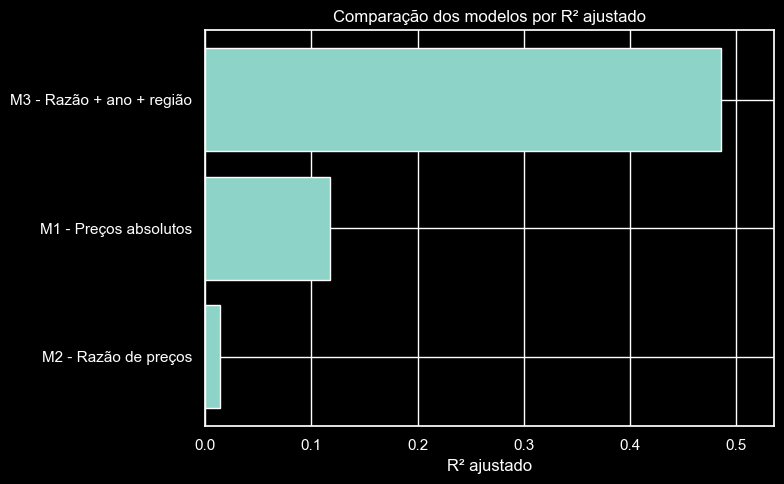

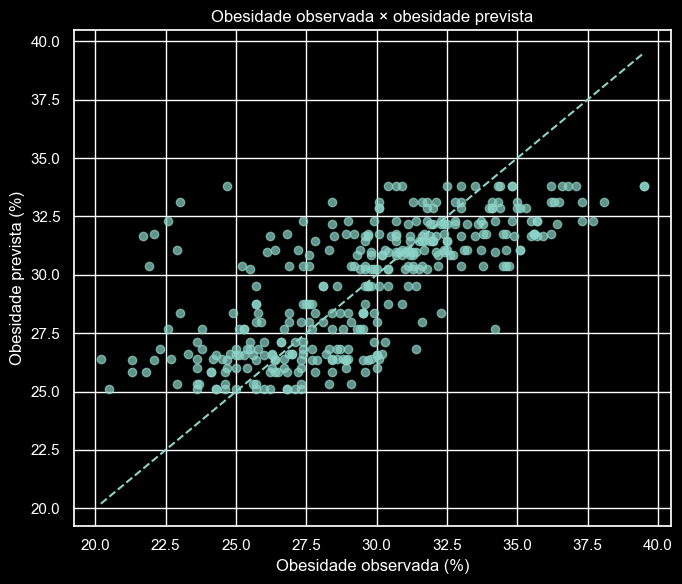

In [52]:
# ── Etapa 10.8 — Comparação visual do poder explicativo dos modelos ──────────

# Gráfico simples em matplotlib para manter compatibilidade entre versões do seaborn.
resumo_plot = resumo_regressoes.sort_values("R2_ajustado", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(resumo_plot["Modelo"], resumo_plot["R2_ajustado"])
plt.title("Comparação dos modelos por R² ajustado")
plt.xlabel("R² ajustado")
plt.ylabel("")
plt.xlim(0, max(resumo_plot["R2_ajustado"].max() + 0.05, 0.05))
plt.tight_layout()
plt.show()

# Valores previstos pelo modelo mais conservador.
dados_pred = dados_m3.copy()
X_pred = sm.add_constant(dados_pred[features_m3], has_constant="add").astype(float)
dados_pred["Obesity_Pred"] = modelo_m3.predict(X_pred)

plt.figure(figsize=(7, 6))
plt.scatter(
    dados_pred["Obesity_Rate"],
    dados_pred["Obesity_Pred"],
    alpha=0.7
)

lim_min = min(dados_pred["Obesity_Rate"].min(), dados_pred["Obesity_Pred"].min())
lim_max = max(dados_pred["Obesity_Rate"].max(), dados_pred["Obesity_Pred"].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")

plt.title("Obesidade observada × obesidade prevista")
plt.xlabel("Obesidade observada (%)")
plt.ylabel("Obesidade prevista (%)")
plt.tight_layout()
plt.show()


In [53]:
# ── Etapa 10.9 — Conclusão automática da regressão ───────────────────────────

from IPython.display import Markdown, display

r2_m1 = modelo_m1.rsquared
r2_m2 = modelo_m2.rsquared
r2_m3 = modelo_m3.rsquared
p_m1 = min(modelo_m1.pvalues.get("Price_Healthy", np.nan), modelo_m1.pvalues.get("Price_Processed", np.nan))
p_m2 = modelo_m2.pvalues.get("Price_Ratio", np.nan)
p_m3 = modelo_m3.pvalues.get("Price_Ratio", np.nan)
coef_ratio_m3 = modelo_m3.params.get("Price_Ratio", np.nan)

if p_m3 < 0.05:
    conclusao_preco = (
        "Após controlar por ano e região, a razão de preços permaneceu estatisticamente "
        "significativa. Isso indica evidência de associação robusta entre disparidade "
        "relativa de preços e taxa de obesidade."
    )
else:
    conclusao_preco = (
        "Após controlar por ano e região, a razão de preços não permaneceu estatisticamente "
        "significativa. Assim, com a base atual, não há evidência estatística robusta para "
        "afirmar que o preço relativo dos alimentos influencia diretamente a obesidade."
    )

texto_conclusao = f"""
### Conclusão da Etapa 10

A regressão foi aplicada usando `Obesity_Rate` como variável alvo e as variáveis de preço como preditores principais. Foram testados três cenários: preços absolutos, razão de preços e razão de preços com controle por ano e região.

- **M1 — Preços absolutos:** R² = {r2_m1:.3f}; menor p-valor entre preços = {p_m1:.4f}.
- **M2 — Razão de preços:** R² = {r2_m2:.3f}; p-valor de `Price_Ratio` = {p_m2:.4f}.
- **M3 — Razão + ano + região:** R² = {r2_m3:.3f}; p-valor de `Price_Ratio` = {p_m3:.4f}; coeficiente de `Price_Ratio` = {coef_ratio_m3:.4f}.

{conclusao_preco}

Portanto, a interpretação deve ser feita como **associação estatística exploratória**, não como causalidade. Uma limitação importante é que os preços do USDA estão agregados por ano e região, enquanto a obesidade está em nível estadual. Por isso, parte da variação capturada pelo modelo pode refletir diferenças temporais e regionais, e não necessariamente um efeito direto do preço dos alimentos.
"""

display(Markdown(texto_conclusao))



### Conclusão da Etapa 10

A regressão foi aplicada usando `Obesity_Rate` como variável alvo e as variáveis de preço como preditores principais. Foram testados três cenários: preços absolutos, razão de preços e razão de preços com controle por ano e região.

- **M1 — Preços absolutos:** R² = 0.122; menor p-valor entre preços = 0.0001.
- **M2 — Razão de preços:** R² = 0.017; p-valor de `Price_Ratio` = 0.0149.
- **M3 — Razão + ano + região:** R² = 0.500; p-valor de `Price_Ratio` = 0.7516; coeficiente de `Price_Ratio` = -6.3501.

Após controlar por ano e região, a razão de preços não permaneceu estatisticamente significativa. Assim, com a base atual, não há evidência estatística robusta para afirmar que o preço relativo dos alimentos influencia diretamente a obesidade.

Portanto, a interpretação deve ser feita como **associação estatística exploratória**, não como causalidade. Uma limitação importante é que os preços do USDA estão agregados por ano e região, enquanto a obesidade está em nível estadual. Por isso, parte da variação capturada pelo modelo pode refletir diferenças temporais e regionais, e não necessariamente um efeito direto do preço dos alimentos.
